In [1]:
import pandas as pd

# 1. Load the data
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# 2. Fix the TotalCharges 'hidden' bug
# We convert it to numeric and force the empty spaces to become 'NaN' (Not a Number)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 3. Handle the 11 missing values
# Since it's only 11 rows out of 7000, we can safely drop them to keep the data pure
df.dropna(inplace=True)

# 4. Remove the customerID
# An ID number doesn't predict churn, so we remove it to keep the model clean
df.drop(columns=['customerID'], inplace=True)

# 5. Verify the fix
print(df.info())
print("\nMissing values remaining:", df.isnull().sum().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

Matplotlib is building the font cache; this may take a moment.
C:\Users\rohit\AppData\Local\Temp\ipykernel_3492\578927992.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


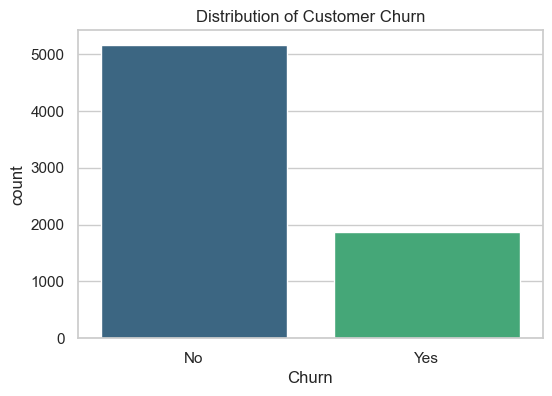

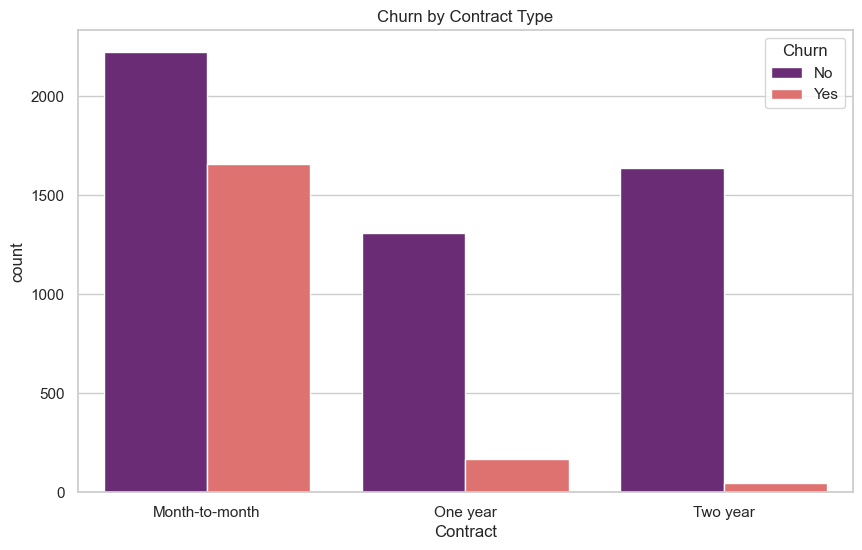

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
sns.set(style="whitegrid")

# 1. Visualize the Churn Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Distribution of Customer Churn')
plt.show()

# 2. Relationship between Contract Type and Churn
# (This is usually the biggest reason for churn)
plt.figure(figsize=(10, 6))
sns.countplot(x='Contract', hue='Churn', data=df, palette='magma')
plt.title('Churn by Contract Type')
plt.show()

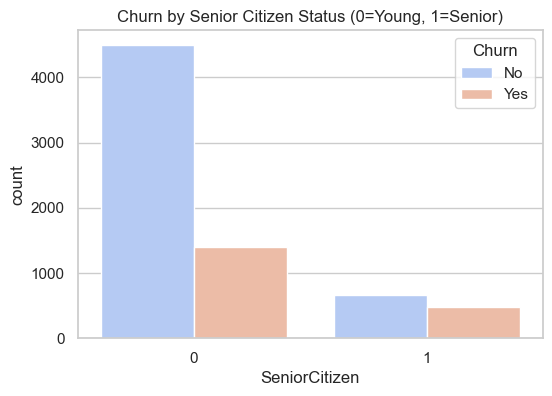

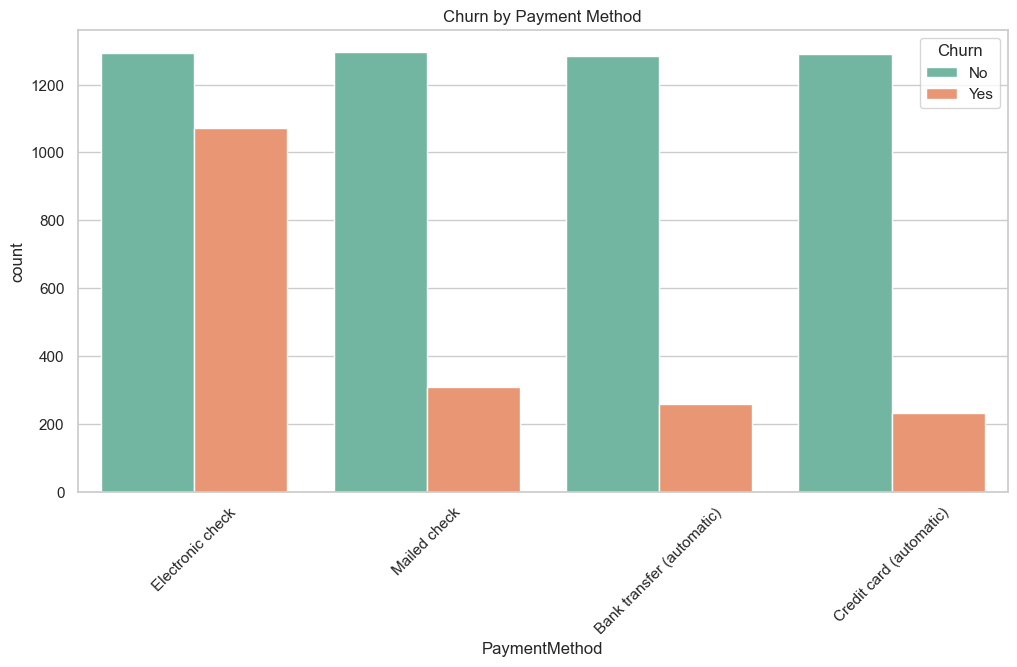

In [5]:
# 1. Churn based on Senior Citizen status
plt.figure(figsize=(6, 4))
sns.countplot(x='SeniorCitizen', hue='Churn', data=df, palette='coolwarm')
plt.title('Churn by Senior Citizen Status (0=Young, 1=Senior)')
plt.show()

# 2. Churn based on Payment Method
plt.figure(figsize=(12, 6))
sns.countplot(x='PaymentMethod', hue='Churn', data=df, palette='Set2')
plt.xticks(rotation=45) # Rotates labels so they don't overlap
plt.title('Churn by Payment Method')
plt.show()

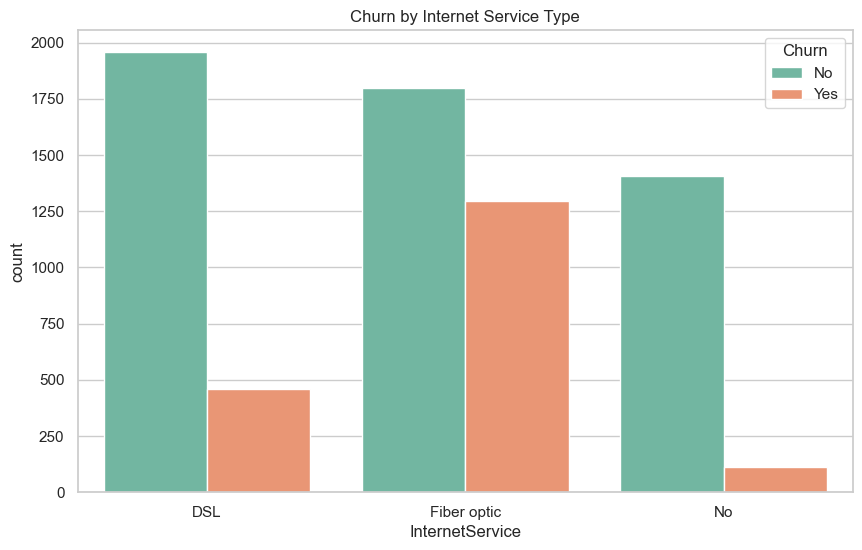

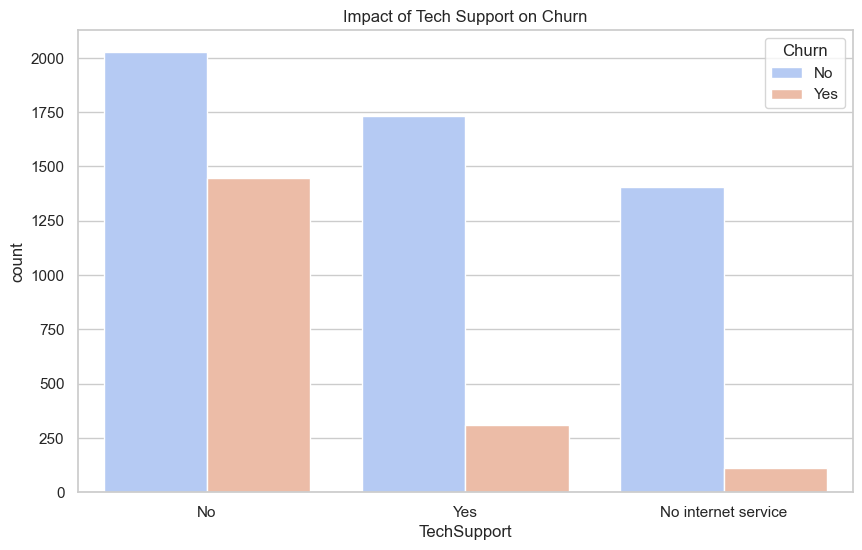

In [7]:
# 1. Churn by Internet Service (Is Fiber Optic a problem?)
plt.figure(figsize=(10, 6))
sns.countplot(x='InternetService', hue='Churn', data=df, palette='Set2')
plt.title('Churn by Internet Service Type')
plt.show()

# 2. Tech Support vs Churn
# We want to see if customers without Tech Support are more likely to leave
plt.figure(figsize=(10, 6))
sns.countplot(x='TechSupport', hue='Churn', data=df, palette='coolwarm')
plt.title('Impact of Tech Support on Churn')
plt.show()

In [11]:
# 1. Convert Churn to binary (Yes=1, No=0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 2. Select the features for our model
# We will use the ones you found (Contract, TechSupport, InternetService) + MonthlyCharges
X = pd.get_dummies(df[['Contract', 'TechSupport', 'InternetService', 'MonthlyCharges', 'tenure']])
y = df['Churn']

# 3. Split the data into Training (80%) and Testing (20%)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (5625, 11)
Testing set size: (1407, 11)


In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Load and Clean (Internal Step)
data = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data.dropna(inplace=True)

# 2. Prepare Features
# Converting text columns to 'Dummy' numbers so the model can read them
X = pd.get_dummies(data[['Contract', 'TechSupport', 'InternetService', 'MonthlyCharges', 'tenure']])
y = data['Churn'].map({'Yes': 1, 'No': 0})

# 3. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train the Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 5. Get Results
y_pred = model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nSuccess! Here is your Classification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 78.61%

Success! Here is your Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



In [22]:
# 1. Calculate the probability of churn for every customer in our data
# We use the 'predict_proba' function - this is the "Secret Sauce"
all_features = pd.get_dummies(data[['Contract', 'TechSupport', 'InternetService', 'MonthlyCharges', 'tenure']])
probabilities = model.predict_proba(all_features)[:, 1] # Get the chance of 'Yes'

# 2. Add the scores back to our original data
data['Churn_Probability'] = (probabilities * 100).round(2)

# 3. Create a "Risk Category"
def categorize_risk(prob):
    if prob > 70: return 'High Risk'
    elif prob > 30: return 'Medium Risk'
    else: return 'Low Risk'

data['Risk_Level'] = data['Churn_Probability'].apply(categorize_risk)

# 4. Export to a NEW CSV for SQL/Power BI
data.to_csv('Churn_Predictions_Final.csv', index=False)

print("Export Successful!")
print(data[['Churn_Probability', 'Risk_Level']].head())

Export Successful!
   Churn_Probability   Risk_Level
0              39.14  Medium Risk
1              10.85     Low Risk
2              45.11  Medium Risk
3               4.11     Low Risk
4              68.25  Medium Risk


In [24]:
import sqlite3

# 1. Create a connection to a virtual database
conn = sqlite3.connect('churn_analysis.db')

# 2. Push your final dataframe into a SQL table called 'Predictions'
data.to_sql('Predictions', conn, if_exists='replace', index=False)

# 3. Test the connection with a simple SQL Query
query = "SELECT Risk_Level, COUNT(*) as Total_Customers FROM Predictions GROUP BY Risk_Level"
sql_result = pd.read_sql(query, conn)

print("SQL Database Ready!")
print(sql_result)

SQL Database Ready!
    Risk_Level  Total_Customers
0    High Risk              284
1     Low Risk             4273
2  Medium Risk             2475
